In [1]:
import random
from tqdm import tqdm
from collections import defaultdict
def get_available_nodes(graph, source, hop=1):
    if hop == 0:
        return set(graph.keys()) - {source}
    current = {source}
    visited = {source}
    available_nodes = set()
    for _ in range(hop):
        next_level = set()
        for node in current:
            neighbors = graph[node]
            available_nodes.update(neighbors)
            for neighbor in neighbors:
                if neighbor not in visited:
                    visited.add(neighbor)
                    next_level.add(neighbor)
        current = next_level
        if not current:
            break
    available_nodes.discard(source)
    return available_nodes

def simulate(graph, victim, originator, available_nodes, p=1):
    if originator not in available_nodes:
        raise ValueError("Originator not in victim neighborhood")
    victim_neighbors = graph[victim]
    remaining = set(victim_neighbors)  # not yet infected
    current = {originator}
    visited = {originator}
    time = 0
    spread_time = 0
    if originator in remaining:
        remaining.remove(originator)

    while current and remaining:
        next_level = set()
        for node in current:
            neighbors = available_nodes & graph[node]
            for neighbor in neighbors:
                spread_prob = random.random()
                if neighbor not in visited and spread_prob <= p:
                    visited.add(neighbor)
                    next_level.add(neighbor)
                    if neighbor in remaining:
                        remaining.remove(neighbor)
                        spread_time = time + 1  # last infection time updates
                elif neighbor not in visited:
                    next_level.add(node)
        current = next_level
        time += 1
    victim_degree = len(victim_neighbors)
    infected = victim_neighbors - remaining
    spread_factor = len(infected) / victim_degree if victim_degree > 0 else 0

    return spread_time, spread_factor

def run_simulation_by_k(graph, hop=1, p=1):
    data_by_k = defaultdict(lambda: defaultdict(list))
    for victim, victim_node in graph.items():
        available_nodes = get_available_nodes(graph, victim, hop=hop)
        for originator in victim_node:
            data = simulate(graph, victim, originator, available_nodes, p)
            spread_time, spread_factor = data[0], data[1]
            k = len(victim_node)
            data_by_k[k]["spread_time"].append(spread_time)
            data_by_k[k]["spread_factor"].append(spread_factor)
    return data_by_k

In [2]:
import pickle
import os
def load_graphs(path):
    with open(path, "rb") as f:
        data = pickle.load(f)
    return data

def save_results(results, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(results, f)

def to_dict(obj):
    if isinstance(obj, defaultdict):
        return {k: to_dict(v) for k, v in obj.items()}
    return obj

In [4]:
for p in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    if not os.path.exists(f"fig_data/fig15/fig15_p{int(p*10):02d}.pkl"):
        result = defaultdict(lambda: defaultdict(list))
        APL_path = f"data/apl/apl_network_g08.pkl"
        APL_graph = load_graphs(APL_path)
        print(f"Running simulation for p={p}:")
        for graph in tqdm([APL_graph]):
            graph_result = run_simulation_by_k(graph, p=p)
            for k, metrics in graph_result.items():
                for metric, values in metrics.items():
                    result[k][metric].extend(values)
        result = to_dict(result)
        del APL_graph
        save_results(result, f"fig_data/fig15/fig15_p{int(p*10):02d}.pkl")
        del result

Running simulation for p=0.1:


100%|██████████| 1/1 [00:04<00:00,  4.52s/it]


Running simulation for p=0.2:


100%|██████████| 1/1 [00:03<00:00,  3.11s/it]


Running simulation for p=0.3:


...

100%|██████████| 1/1 [00:01<00:00,  1.09s/it]


Running simulation for p=0.9:


100%|██████████| 1/1 [00:00<00:00,  1.27it/s]


Running simulation for p=1.0:


100%|██████████| 1/1 [00:00<00:00,  1.48it/s]


Fig 15


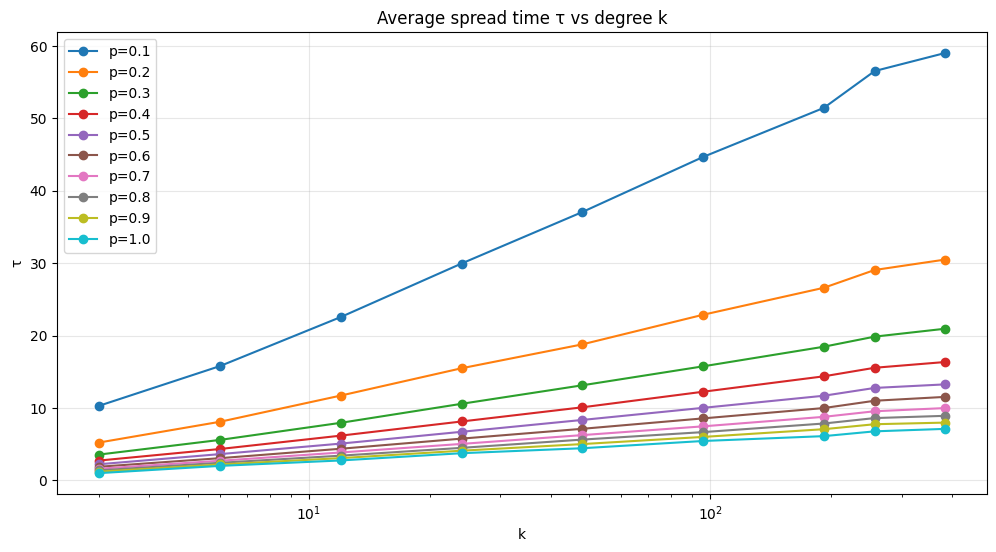

In [23]:
import matplotlib.pyplot as plt
import numpy as np

Bs = []

#Spread time
plt.figure(figsize=(12, 6))
for p in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    APL_data_by_k = load_graphs(f"fig_data/fig15/fig15_p{int(p * 10):02d}.pkl")
    APL_plot_data_by_k = defaultdict(dict)
    for k in APL_data_by_k:
        APL_plot_data_by_k[k]["spread_time"] = sum(APL_data_by_k[k]["spread_time"]) / len(APL_data_by_k[k]["spread_time"])
    ks = np.array(sorted(APL_plot_data_by_k))
    spread_times = np.array([APL_plot_data_by_k[k]["spread_time"] for k in ks])
    plt.plot(ks, spread_times, label=f"p={p}", marker="o")

    a,b = np.polyfit(np.log(ks), spread_times, 1)
    Bs.append(a)
    del APL_data_by_k, APL_plot_data_by_k

print("Fig 15")
plt.xscale("log")
plt.xlabel("k")
plt.ylabel("τ")
plt.title("Average spread time τ vs degree k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Slope B: -0.8998, Intercept: 0.2403
Fig 15 inset


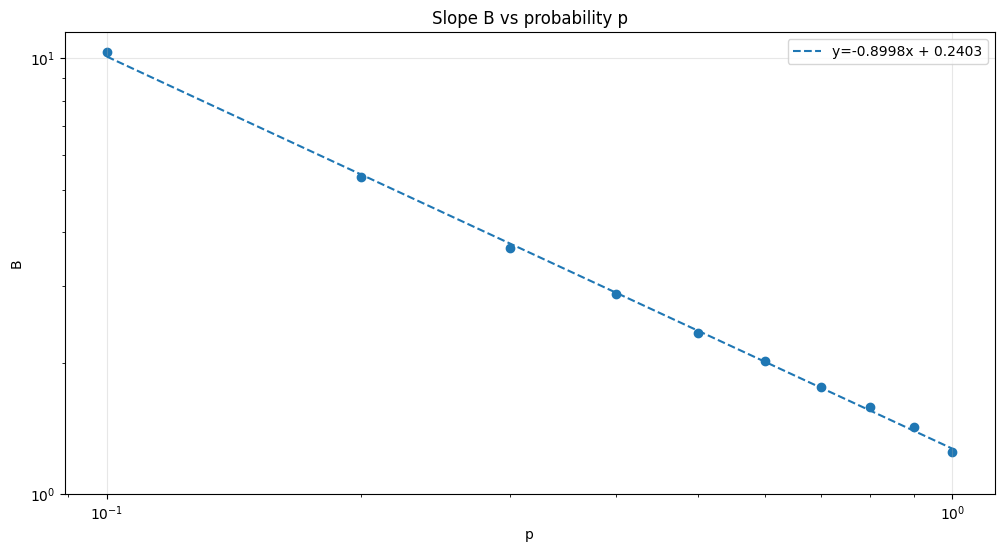

In [31]:
#Spread time
plt.figure(figsize=(12, 6))
"""APL_data_by_p = defaultdict(list)

for p in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    APL_data_by_k = load_graphs(f"fig_data/fig15/fig15_p{int(p * 10):02d}.pkl")
    for k in APL_data_by_k:
        APL_data_by_p[p].extend(APL_data_by_k[k]["spread_time"])
del APL_data_by_k

ps = sorted(APL_data_by_p)
avg_spread_times = [sum(APL_data_by_p[p]) / len(APL_data_by_p[p]) for p in ps]"""
ps = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
a,b = np.polyfit(np.log(ps), np.log(Bs), 1)
print(f"Slope B: {a:.4f}, Intercept: {b:.4f}")
plt.scatter(ps, Bs, marker="o")
plt.plot(ps, np.exp(a * np.log(ps) + b), label=f"y={a:.4f}x + {b:.4f}", linestyle="--")

print("Fig 15 inset")
plt.xscale("log")
plt.yscale("log")
plt.ylim(bottom=1)
plt.xlabel("p")
plt.ylabel("B")
plt.title("Slope B vs probability p")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()